In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Jun  4 21:33:25 2022

@author: ixn004
"""
#July 10, 2025


import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time

#from pyswarm import pso
from pyswarms.single.global_best import GlobalBestPSO #Date: Macrh 30,2024
from calculate_pZAP import run_bionetgen
from interpolation import spline
from ca_ODE import calcium, solve
from interpolation_exp_data import exp_idata


from data_slice import data_after_tstart
from ZAP_SYK_SSR_fit import calculate_residue
from calculate_SSR_gamma import gamma_PZAP
from calculate_SSR_zeta import zeta_PZAP    
from calculate_SSR_mixed import mixed_PZAP
import sys
      


In [2]:
# data_gamma=pd.read_csv('../hCD16_Ca_expt/ca_data/gamma.dat',sep="\t", comment='#', header=None)
# data_zeta=pd.read_csv('../hCD16_Ca_expt/ca_data/zeta.dat',sep="\t", comment='#', header=None)
# data_mixed=pd.read_csv('../hCD16_Ca_expt/ca_data/mixed.dat',sep="\t", comment='#', header=None)


data_gamma=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/gamma_scaled.dat',sep="\t", comment='#', header=None)
data_zeta=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/zeta_scaled.dat',sep="\t", comment='#', header=None)
data_mixed=pd.read_csv('../../../hCD16_Ca_expt/ca_data/scaled_data/mixed_scaled.dat',sep="\t", comment='#', header=None)

global exp_time_gamma, exp_data_gamma, exp_time_zeta, exp_data_zeta, exp_time_mixed, exp_data_mixed
#if the data has a time column:
start_time=time.time()

data_gamma=np.asarray(data_gamma) 
data_zeta=np.asarray(data_zeta)
data_mixed=np.asarray(data_mixed)

exp_time_gamma=data_gamma[:,0]
exp_data_gamma=data_gamma[:,1]

exp_time_zeta=data_zeta[:,0]
exp_data_zeta=data_zeta[:,1]

exp_time_mixed=data_mixed[:,0]
exp_data_mixed=data_mixed[:,1]


In [3]:
estimates=[4.882889227827497, -0.14924883865790955, -2.091248419834949, 2.6558849182283195, 3.189827436504974, 3.183417389060109, 561.7418221960589]

C1 = 10**estimates[0]
C2 = 10**estimates[1]
g = 10**estimates[2]

a0_zeta=120
a0_mixed= a0_zeta*1.6 
a0_gamma= a0_zeta*0.53
ZAP0= 1131.0
SYK0= 754.0

dir_name="analysis"
print(f"C1={C1}")
print(f"C2={C2}")
print(f"g={g}")
print(f"a0_zeta={a0_zeta}")
print(f"a0_mixed={a0_mixed}")
print(f"a0_gamma={a0_gamma}")
print(f"ZAP0={ZAP0}")
print(f"SYK0={SYK0}")

C1=76364.0982669576
C2=0.7091713160937018
g=0.008104973144412215
a0_zeta=120
a0_mixed=192.0
a0_gamma=63.6
ZAP0=1131.0
SYK0=754.0


In [4]:
zeta=pd.read_csv('zeta_results.txt',sep='\t',header=None)
tnew_zeta = zeta.iloc[:, 0].values
PZAP_zeta = zeta.iloc[:,1].values
PSYK_zeta = zeta.iloc[:,2].values

# print("tnew_zeta:", tnew_zeta)
# print("PZAP_zeta:", PZAP_zeta)
# print("PSYK_zeta:", PSYK_zeta)

mixed=pd.read_csv('mixed_results.txt',sep='\t',header=None)
tnew_mixed = mixed.iloc[:, 0].values
PZAP_mixed = mixed.iloc[:,1].values
PSYK_mixed = mixed.iloc[:,2].values

gamma=pd.read_csv('gamma_results.txt',sep='\t',header=None)
tnew_gamma = gamma.iloc[:, 0].values
PZAP_gamma = gamma.iloc[:,1].values
PSYK_gamma = gamma.iloc[:,2].values


In [5]:
n=3
N=2000

k3=(np.max(PZAP_zeta))/2.0
k4=(np.max(PZAP_zeta))/2.0

In [6]:
factor=1.0


residue_zeta,t_zeta,EXPT_zeta,Ca_zeta = calculate_residue(n, tnew_zeta, PZAP_zeta, PSYK_zeta, exp_time_zeta, exp_data_zeta, C1*factor, C2*factor, g, N, k3,k4)
residue_mixed,t_mixed,EXPT_mixed,Ca_mixed = calculate_residue(n, tnew_mixed, PZAP_mixed, PSYK_mixed, exp_time_mixed, exp_data_mixed, C1*factor, C2*factor, g, N, k3,k4)
residue_gamma,t_gamma,EXPT_gamma,Ca_gamma = calculate_residue(n, tnew_gamma, PZAP_gamma, PSYK_gamma, exp_time_gamma, exp_data_gamma, C1*factor, C2*factor, g, N, k3,k4)

C1 = 76364.0982669576
C2 = 0.7091713160937018
g = 0.008104973144412215
ca0 in main 38689.53125
[38689.53125    38647.82705064 38606.16780605 ... 18338.9670739
 18319.19937382 18299.45298155]
C1 = 76364.0982669576
C2 = 0.7091713160937018
g = 0.008104973144412215
ca0 in main 41737.61328
[41737.61328    41692.62349365 41647.68220909 ... 19588.40968012
 19567.2951901  19546.20345959]
C1 = 76364.0982669576
C2 = 0.7091713160937018
g = 0.008104973144412215
ca0 in main 36345.51172
[36345.51172    36306.33418494 36267.19886626 ... 33323.22615193
 33292.80223086 33262.31153078]


Total residue^(1/4) = 565.7649


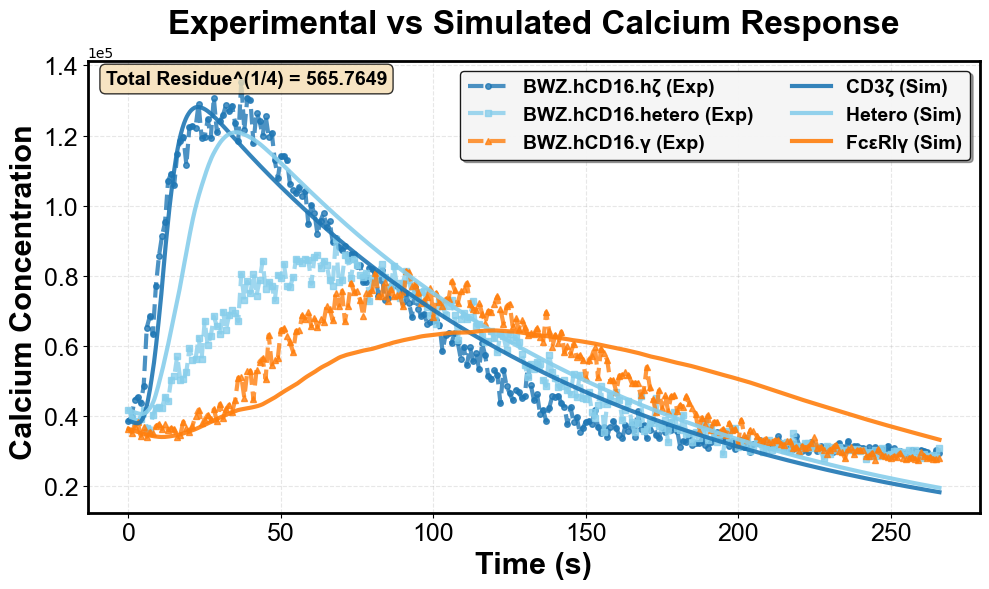

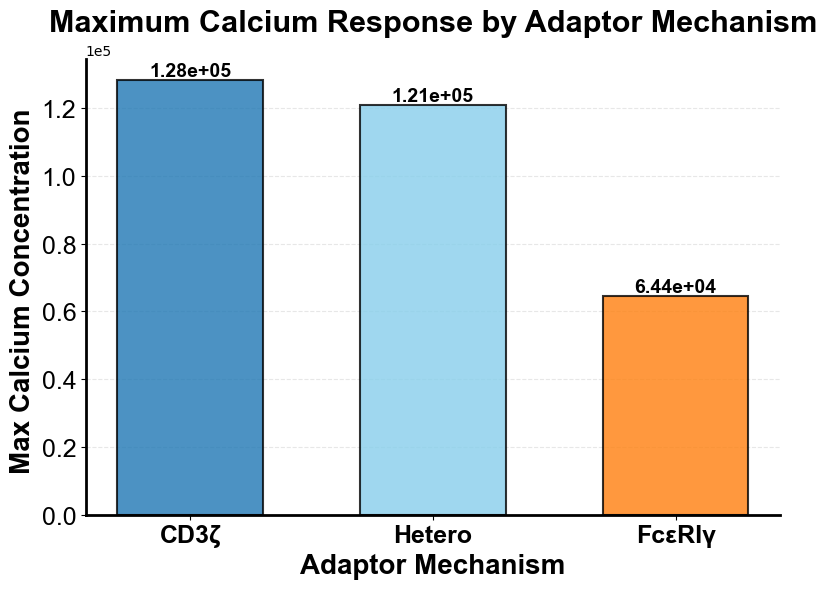

In [7]:
Vc=25.0 #pZAP molecules in the simulation box of size 25 um^3
z=602.0 #constant factor to convert from molecules/um3 to uM



# # Enhanced pZAP time series plot
# fig, ax = plt.subplots(figsize=(10, 6))

# # Plot with enhanced styling
# ax.plot(tnew_zeta, PZAP_zeta, label='CD3ζ', color='#1f77b4', linewidth=3, alpha=0.9)
# ax.plot(tnew_mixed, PZAP_mixed, label='Hetero', color='#87ceeb', linewidth=3, alpha=0.9)
# ax.plot(tnew_gamma, PZAP_gamma, label='FcεRIγ', color='#ff7f0e', linewidth=3, alpha=0.9)

# # Customize labels and title
# ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
# ax.set_ylabel('Bound pZAP70', fontfamily='Arial', fontsize=22, fontweight='bold')
# ax.set_title('pZAP70 Time Evolution by Adaptor Mechanism', 
#              fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# # Enhanced tick formatting
# ax.tick_params(axis='both', which='major', labelsize=18)
# plt.setp(ax.get_xticklabels(), fontfamily='Arial')
# plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# # Enhanced legend
# legend = ax.legend(prop={'family': 'Arial', 'size': 18, 'weight': 'bold'}, 
#                    frameon=True, fancybox=True, shadow=True, 
#                    framealpha=0.9, edgecolor='black')

# # Add grid
# ax.grid(True, alpha=0.3, linestyle='--')
# ax.set_axisbelow(True)

# # Set spine styling
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
#     spine.set_color('black')

# # Scientific notation if needed
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# plt.tight_layout()
# #plt.show()

# # Create figure with better design
# fig, ax = plt.subplots(figsize=(8, 6))

# # Data and labels
# mechanisms = ['CD3ζ', 'Hetero', 'FcεRIγ']
# max_values = [np.max(PZAP_zeta), np.max(PZAP_mixed), np.max(PZAP_gamma)]
# colors = ['#1f77b4', '#87ceeb', '#ff7f0e']  # Professional color palette

# # Create bars with enhanced styling
# bars = ax.bar(mechanisms, max_values, 
#               color=colors, 
#               alpha=0.8,
#               edgecolor='black',
#               linewidth=1.5,
#               width=0.6)

# # Add value labels on top of bars
# for bar, value in zip(bars, max_values):
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height,
#             f'{value:.3f}',
#             ha='center', va='bottom', 
#             fontfamily='Arial', fontsize=14, fontweight='bold')

# # Customize the plot
# ax.set_ylabel('Max pZAP', fontfamily='Arial', fontsize=20, fontweight='bold')
# ax.set_xlabel('Adaptor Mechanism', fontfamily='Arial', fontsize=20, fontweight='bold')
# ax.set_title('Maximum pZAP70 Levels by Adaptor Mechanism', 
#              fontfamily='Arial', fontsize=22, fontweight='bold', pad=20)

# # Set tick parameters
# ax.tick_params(axis='both', which='major', labelsize=18)
# plt.setp(ax.get_xticklabels(), fontfamily='Arial', fontweight='bold')
# plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# # Add grid for better readability
# ax.grid(True, alpha=0.3, linestyle='--', axis='y')
# ax.set_axisbelow(True)

# # Set spine thickness and style
# for spine in ax.spines.values():
#     spine.set_linewidth(2)
#     spine.set_color('black')

# # Remove top and right spines for cleaner look
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# # Scientific notation for y-axis if needed
# ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# # Adjust layout and show
# plt.tight_layout()
# #plt.show()


# Enhanced experimental vs simulation calcium plot
fig, ax = plt.subplots(figsize=(10, 6))


# Experimental data with enhanced styling
ax.plot(exp_time_zeta, exp_data_zeta, color='#1f77b4', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.hζ (Exp)', marker='o', markersize=4)
ax.plot(exp_time_mixed, exp_data_mixed, color='#87ceeb', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.hetero (Exp)', marker='s', markersize=4)
ax.plot(exp_time_gamma, exp_data_gamma, color='#ff7f0e', linewidth=3, 
        linestyle='--', alpha=0.8, label='BWZ.hCD16.γ (Exp)', marker='^', markersize=4)

# Simulation data with solid lines
ax.plot(t_zeta, Ca_zeta, color='#1f77b4', linewidth=3, alpha=0.9, label='CD3ζ (Sim)')
ax.plot(t_mixed, Ca_mixed, color='#87ceeb', linewidth=3, alpha=0.9, label='Hetero (Sim)')
ax.plot(t_gamma, Ca_gamma, color='#ff7f0e', linewidth=3, alpha=0.9, label='FcεRIγ (Sim)')

# Calculate and display residue
# Calculate and display residue
#residue_total = residue_zeta #+ residue_gamma
residue_total = residue_zeta  #+ residue_mixed
print(f"Total residue^(1/4) = {residue_total**(1/4):.4f}")

# Enhanced labels and title
ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_ylabel('Calcium Concentration ', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_title('Experimental vs Simulated Calcium Response', 
             fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Enhanced legend with two columns
legend = ax.legend(prop={'family': 'Arial', 'size': 14, 'weight': 'bold'}, 
                   frameon=True, fancybox=True, shadow=True, 
                   framealpha=0.9, edgecolor='black', ncol=2, loc='upper right')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set spine styling
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Scientific notation if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Add text box with residue information
textstr = f'Total Residue^(1/4) = {residue_total**(1/4):.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=14,
        verticalalignment='top', bbox=props, fontfamily='Arial', fontweight='bold')

plt.tight_layout()
plt.show()

# Enhanced maximum calcium bar plot
fig, ax = plt.subplots(figsize=(8, 6))

# Data and labels
mechanisms = ['CD3ζ', 'Hetero', 'FcεRIγ']
max_calcium_values = [np.max(Ca_zeta), np.max(Ca_mixed), np.max(Ca_gamma)]
colors = ['#1f77b4', '#87ceeb', '#ff7f0e']  # Professional color palette

# Create bars with enhanced styling
bars = ax.bar(mechanisms, max_calcium_values, 
              color=colors, 
              alpha=0.8,
              edgecolor='black',
              linewidth=1.5,
              width=0.6)

# Add value labels on top of bars
for bar, value in zip(bars, max_calcium_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:.2e}',
            ha='center', va='bottom', 
            fontfamily='Arial', fontsize=14, fontweight='bold')

# Customize the plot
ax.set_ylabel('Max Calcium Concentration ', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_xlabel('Adaptor Mechanism', fontfamily='Arial', fontsize=20, fontweight='bold')
ax.set_title('Maximum Calcium Response by Adaptor Mechanism', 
             fontfamily='Arial', fontsize=22, fontweight='bold', pad=20)

# Set tick parameters
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial', fontweight='bold')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', axis='y')
ax.set_axisbelow(True)

# Set spine thickness and style
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Remove top and right spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Scientific notation for y-axis
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Adjust layout and show
plt.tight_layout()
plt.show()


factor=1
C1 = 76364.0982669576
C2 = 0.7091713160937018
g = 0.008104973144412215
ca0 in main 38689.53125
[38689.53125    38647.82705064 38606.16780605 ... 18338.9670739
 18319.19937382 18299.45298155]
Total residue^(1/4) = 565.7649
factor=0.9
C1 = 68727.68844026185
C2 = 0.6382541844843316
g = 0.008104973144412215
ca0 in main 38689.53125
[38689.53125    38647.82705064 38606.16780448 ... 18394.80903583
 18374.9811418  18355.17462048]
Total residue^(1/4) = 571.1390
factor=0.8
C1 = 61091.278613566086
C2 = 0.5673370528749614
g = 0.008104973144412215
ca0 in main 38689.53125
[38689.53125    38647.82705064 38606.1678029  ... 18461.79658361
 18441.89648173 18422.01783039]
Total residue^(1/4) = 579.7057
factor=0.7
C1 = 53454.86878687032
C2 = 0.4964199212655912
g = 0.008104973144412215
ca0 in main 38689.53125
[38689.53125    38647.82705064 38606.16780132 ... 18544.15820502
 18524.16932347 18504.20198814]
Total residue^(1/4) = 592.6656
factor=0.6
C1 = 45818.45896017456
C2 = 0.42550278965622107
g = 

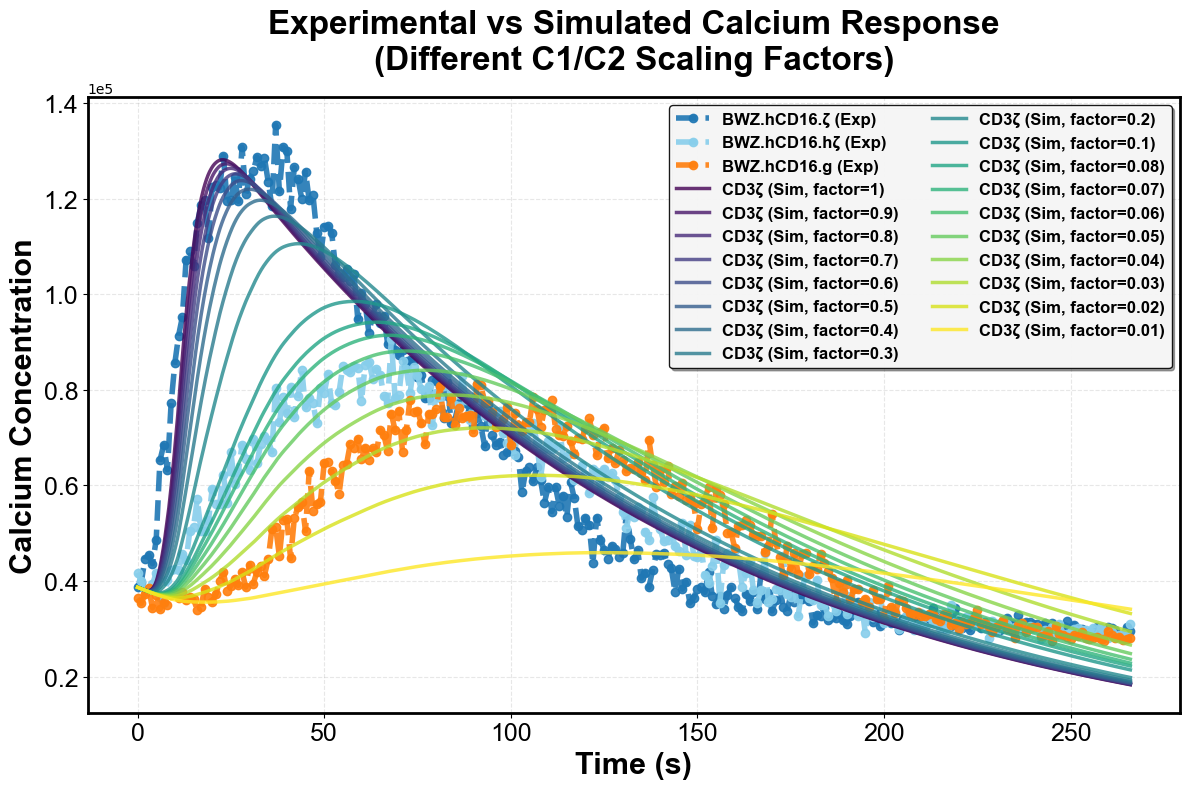

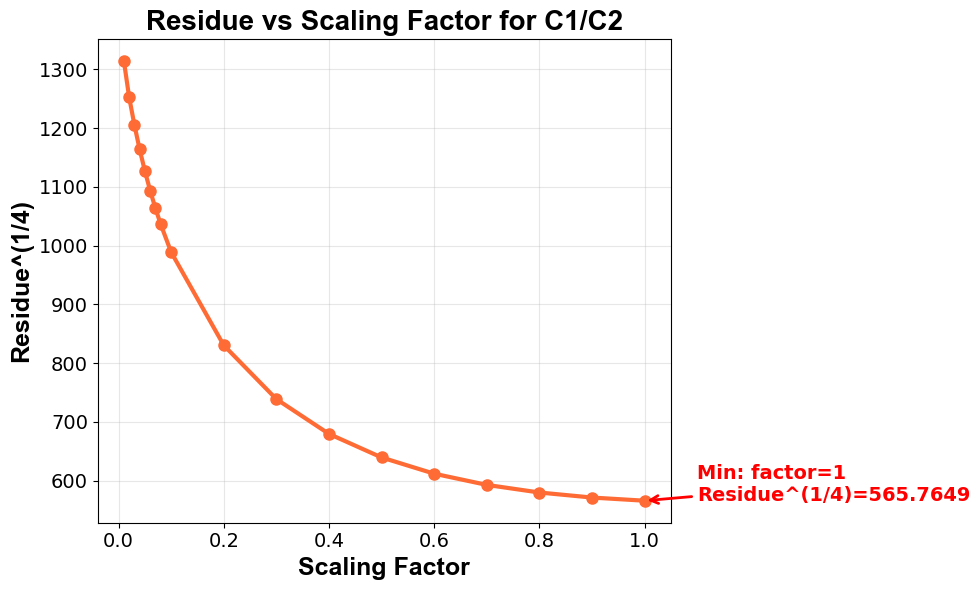


Summary:
Best factor: 1
Minimum residue^(1/4): 565.7649


In [8]:
factor=[1,0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.08,0.07,0.06,0.05,0.04,0.03,0.02,0.01]

# Create a single figure for all factors
fig, ax = plt.subplots(figsize=(12, 8))

# Plot experimental data once
ax.plot(exp_time_zeta, exp_data_zeta, color='#1f77b4', linewidth=4, 
        linestyle='--', alpha=0.9, label='BWZ.hCD16.ζ (Exp)', marker='o', markersize=6)

ax.plot(exp_time_mixed, exp_data_mixed, color='#87ceeb', linewidth=4, 
        linestyle='--', alpha=0.9, label='BWZ.hCD16.hζ (Exp)', marker='o', markersize=6)

ax.plot(exp_time_gamma, exp_data_gamma, color='#ff7f0e', linewidth=4, 
        linestyle='--', alpha=0.9, label='BWZ.hCD16.g (Exp)', marker='o', markersize=6)
# Define colors for different factors
colors = plt.cm.viridis(np.linspace(0, 1, len(factor)))

# Store residue values for summary
residue_values = []

for i in range(len(factor)):
    print(f"factor={factor[i]}")
    
    # Calculate residues for each factor
    residue_zeta,t_zeta,EXPT_zeta,Ca_zeta = calculate_residue(n, tnew_zeta, PZAP_zeta, PSYK_zeta, exp_time_zeta, exp_data_zeta, C1*factor[i], C2*factor[i], g, N, k3,k4)
    
    # Store residue value
    residue_values.append(residue_zeta**(1/4))
    
    # Plot simulation data with different colors for each factor
    ax.plot(t_zeta, Ca_zeta, color=colors[i], linewidth=2.5, alpha=0.8, 
            label=f'CD3ζ (Sim, factor={factor[i]})')
    
    print(f"Total residue^(1/4) = {residue_zeta**(1/4):.4f}")

# Enhanced labels and title
ax.set_xlabel('Time (s)', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_ylabel('Calcium Concentration', fontfamily='Arial', fontsize=22, fontweight='bold')
ax.set_title('Experimental vs Simulated Calcium Response\n(Different C1/C2 Scaling Factors)', 
            fontfamily='Arial', fontsize=24, fontweight='bold', pad=20)

# Enhanced tick formatting
ax.tick_params(axis='both', which='major', labelsize=18)
plt.setp(ax.get_xticklabels(), fontfamily='Arial')
plt.setp(ax.get_yticklabels(), fontfamily='Arial')

# Enhanced legend
legend = ax.legend(prop={'family': 'Arial', 'size': 12, 'weight': 'bold'}, 
                   frameon=True, fancybox=True, shadow=True, 
                   framealpha=0.9, edgecolor='black', ncol=2, loc='upper right')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Set spine styling
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Scientific notation if needed
ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

plt.tight_layout()
plt.show()

# Create a summary plot of residue vs factor
fig2, ax2 = plt.subplots(figsize=(10, 6))

ax2.plot(factor, residue_values, 'o-', linewidth=3, markersize=8, color='#ff6b35')
ax2.set_xlabel('Scaling Factor', fontfamily='Arial', fontsize=18, fontweight='bold')
ax2.set_ylabel('Residue^(1/4)', fontfamily='Arial', fontsize=18, fontweight='bold')
ax2.set_title('Residue vs Scaling Factor for C1/C2', fontfamily='Arial', fontsize=20, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=14)

# Annotate minimum residue
min_idx = np.argmin(residue_values)
min_factor = factor[min_idx]
min_residue = residue_values[min_idx]

ax2.annotate(f'Min: factor={min_factor}\nResidue^(1/4)={min_residue:.4f}', 
            xy=(min_factor, min_residue), xytext=(min_factor+0.1, min_residue+0.05),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=14, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"Best factor: {min_factor}")
print(f"Minimum residue^(1/4): {min_residue:.4f}")

Factor Analysis - Peak Position and Peak Value:
Analyzing factor=1
C1 = 76364.0982669576
C2 = 0.7091713160937018
g = 0.008104973144412215
ca0 in main 38689.53125
[38689.53125    38647.82705064 38606.16780605 ... 18338.9670739
 18319.19937382 18299.45298155]
  Peak time: 22.75 s, Peak Ca: 1.281e+05, Residue^(1/4): 565.7649
Analyzing factor=0.9
C1 = 68727.68844026185
C2 = 0.6382541844843316
g = 0.008104973144412215
ca0 in main 38689.53125
[38689.53125    38647.82705064 38606.16780448 ... 18394.80903583
 18374.9811418  18355.17462048]
  Peak time: 23.69 s, Peak Ca: 1.273e+05, Residue^(1/4): 571.1390
Analyzing factor=0.8
C1 = 61091.278613566086
C2 = 0.5673370528749614
g = 0.008104973144412215
ca0 in main 38689.53125
[38689.53125    38647.82705064 38606.1678029  ... 18461.79658361
 18441.89648173 18422.01783039]
  Peak time: 25.02 s, Peak Ca: 1.263e+05, Residue^(1/4): 579.7057
Analyzing factor=0.7
C1 = 53454.86878687032
C2 = 0.4964199212655912
g = 0.008104973144412215
ca0 in main 38689.5312

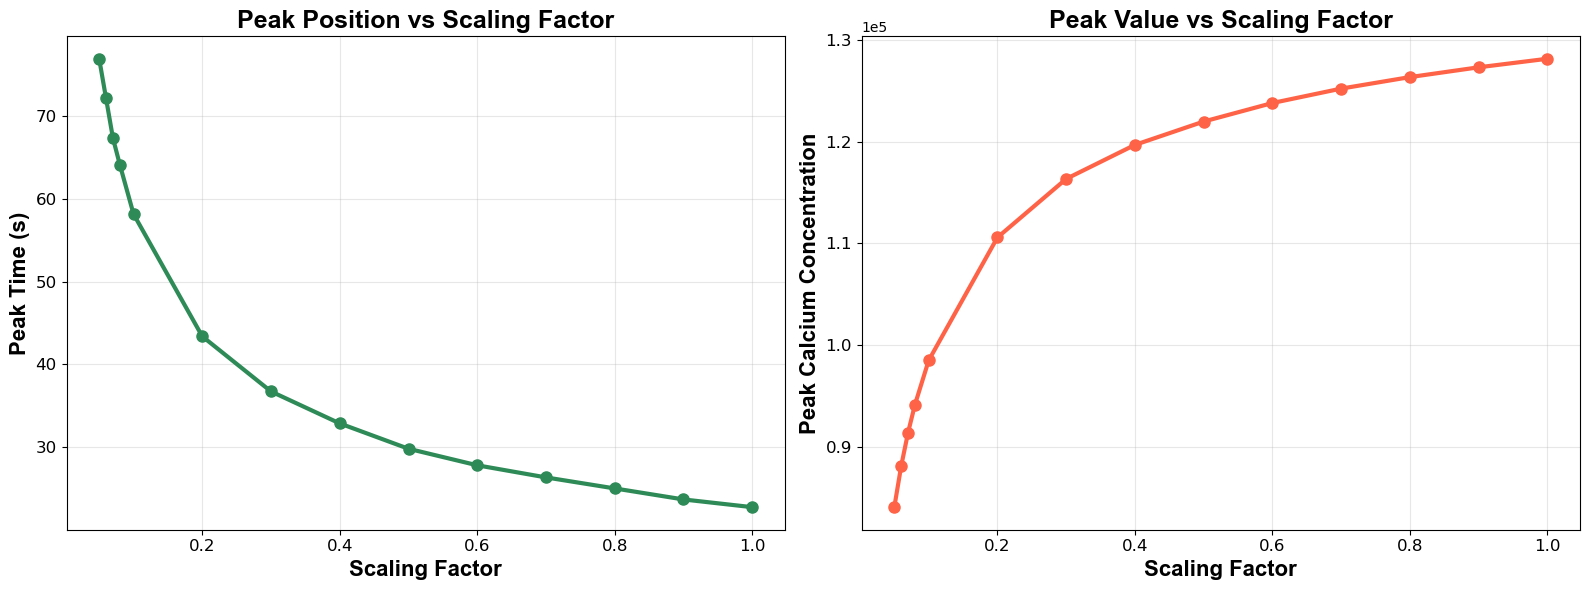


Summary Statistics:
Peak Position Range: 22.75 - 76.91 s
Peak Value Range: 8.410e+04 - 1.281e+05
Best factor (lowest residue): 1
Factor for earliest peak: 1 (at 22.75 s)
Factor for highest peak: 1 (value: 1.281e+05)


In [9]:
# Additional analysis: Peak position and peak value vs factor
factor=[1,0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1,0.08,0.07,0.06,0.05]

# Store peak positions and peak values for analysis
peak_positions = []
peak_values = []
residue_values_analysis = []

print("Factor Analysis - Peak Position and Peak Value:")
print("=" * 50)

for i in range(len(factor)):
    print(f"Analyzing factor={factor[i]}")
    
    # Calculate residues for each factor
    residue_zeta,t_zeta,EXPT_zeta,Ca_zeta = calculate_residue(n, tnew_zeta, PZAP_zeta, PSYK_zeta, exp_time_zeta, exp_data_zeta, C1*factor[i], C2*factor[i], g, N, k3,k4)
    
    # Find peak position (time at maximum calcium)
    max_idx = np.argmax(Ca_zeta)
    peak_time = t_zeta[max_idx]
    peak_ca_value = Ca_zeta[max_idx]
    
    # Store values
    peak_positions.append(peak_time)
    peak_values.append(peak_ca_value)
    residue_values_analysis.append(residue_zeta**(1/4))
    
    print(f"  Peak time: {peak_time:.2f} s, Peak Ca: {peak_ca_value:.3e}, Residue^(1/4): {residue_zeta**(1/4):.4f}")

print("=" * 50)

# Create subplot figure for peak analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Factor vs Peak Position
ax1.plot(factor, peak_positions, 'o-', linewidth=3, markersize=8, color='#2E8B57')
ax1.set_xlabel('Scaling Factor', fontfamily='Arial', fontsize=16, fontweight='bold')
ax1.set_ylabel('Peak Time (s)', fontfamily='Arial', fontsize=16, fontweight='bold')
ax1.set_title('Peak Position vs Scaling Factor', fontfamily='Arial', fontsize=18, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=12)

# Plot 2: Factor vs Peak Value
ax2.plot(factor, peak_values, 'o-', linewidth=3, markersize=8, color='#FF6347')
ax2.set_xlabel('Scaling Factor', fontfamily='Arial', fontsize=16, fontweight='bold')
ax2.set_ylabel('Peak Calcium Concentration', fontfamily='Arial', fontsize=16, fontweight='bold')
ax2.set_title('Peak Value vs Scaling Factor', fontfamily='Arial', fontsize=18, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))

# Adjust layout
plt.tight_layout()
plt.show()

# Summary statistics
min_res_idx = np.argmin(residue_values_analysis)
min_peak_idx = np.argmin(peak_positions)
max_val_idx = np.argmax(peak_values)

print(f"\nSummary Statistics:")
print(f"Peak Position Range: {min(peak_positions):.2f} - {max(peak_positions):.2f} s")
print(f"Peak Value Range: {min(peak_values):.3e} - {max(peak_values):.3e}")
print(f"Best factor (lowest residue): {factor[min_res_idx]}")
print(f"Factor for earliest peak: {factor[min_peak_idx]} (at {peak_positions[min_peak_idx]:.2f} s)")
print(f"Factor for highest peak: {factor[max_val_idx]} (value: {peak_values[max_val_idx]:.3e})")

In [ ]:
# Parameter estimation using pyswarm for 5 parameters: C1, C2, g, k3, k4
# Import pyswarm
try:
    from pyswarm import pso
    print("Using pyswarm library")
except ImportError:
    print("pyswarm not available, using pyswarms as alternative")
    from pyswarms.single.global_best import GlobalBestPSO

# Define the cost function for parameter estimation
def cost_function_5param(params):
    """
    Cost function for 5-parameter optimization: C1, C2, g, k3, k4
    params: [log10(C1), log10(C2), log10(g), log10(k3), log10(k4)]
    Returns: combined residue from all three mechanisms
    """
    try:
        # Extract parameters from log space
        C1_opt = 10**params[0]
        C2_opt = 10**params[1] 
        g_opt = 10**params[2]
        k3_opt = 10**params[3]
        k4_opt = 10**params[4]
        
        # Calculate residues for all three mechanisms
        residue_zeta_opt, _, _, _ = calculate_residue(
            n, tnew_zeta, PZAP_zeta, PSYK_zeta, 
            exp_time_zeta, exp_data_zeta, 
            C1_opt, C2_opt, g_opt, N, k3_opt, k4_opt
        )
        
        residue_mixed_opt, _, _, _ = calculate_residue(
            n, tnew_mixed, PZAP_mixed, PSYK_mixed, 
            exp_time_mixed, exp_data_mixed, 
            C1_opt, C2_opt, g_opt, N, k3_opt, k4_opt
        )
        
        residue_gamma_opt, _, _, _ = calculate_residue(
            n, tnew_gamma, PZAP_gamma, PSYK_gamma, 
            exp_time_gamma, exp_data_gamma, 
            C1_opt, C2_opt, g_opt, N, k3_opt, k4_opt
        )
        
        # Combined cost function
        total_cost = residue_zeta_opt + residue_mixed_opt + residue_gamma_opt
        
        print(f"Params: C1={C1_opt:.2e}, C2={C2_opt:.2e}, g={g_opt:.2e}, k3={k3_opt:.2e}, k4={k4_opt:.2e}")
        print(f"Residues: zeta={residue_zeta_opt:.4f}, mixed={residue_mixed_opt:.4f}, gamma={residue_gamma_opt:.4f}")
        print(f"Total cost: {total_cost:.4f}")
        print("-" * 80)
        
        return total_cost
        
    except Exception as e:
        print(f"Error in cost function: {e}")
        return 1e10  # Return large penalty for failed evaluations

# Set parameter bounds (in log10 space)
# Based on current parameter values and reasonable ranges
lb = [3.0,   # log10(C1) - lower bound around 1e3
      -3.0,  # log10(C2) - lower bound around 1e-3  
      -4.0,  # log10(g) - lower bound around 1e-4
      -3.0,  # log10(k3) - lower bound around 1e-3
      -3.0]  # log10(k4) - lower bound around 1e-3

ub = [6.0,   # log10(C1) - upper bound around 1e6
      1.0,   # log10(C2) - upper bound around 10
      -1.0,  # log10(g) - upper bound around 0.1
      2.0,   # log10(k3) - upper bound around 100
      2.0]   # log10(k4) - upper bound around 100

# Initial guess based on current parameters
initial_guess = [np.log10(C1),     # log10(C1)
                np.log10(C2),      # log10(C2) 
                np.log10(g),       # log10(g)
                np.log10(k3),      # log10(k3)
                np.log10(k4)]      # log10(k4)

print("Parameter Estimation Setup:")
print("=" * 50)
print(f"Initial guess (log10): {initial_guess}")
print(f"Current values: C1={C1:.2e}, C2={C2:.2e}, g={g:.2e}, k3={k3:.2e}, k4={k4:.2e}")
print(f"Lower bounds (log10): {lb}")
print(f"Upper bounds (log10): {ub}")
print("=" * 50)

# Test the cost function with initial parameters
print("Testing cost function with initial parameters...")
initial_cost = cost_function_5param(initial_guess)
print(f"Initial cost: {initial_cost:.4f}")
print("=" * 50)

# PSO parameters
swarmsize = 30    # Number of particles
maxiter = 100     # Maximum iterations
minstep = 1e-8    # Minimum step size
minfunc = 1e-8    # Minimum function tolerance

print(f"PSO Settings:")
print(f"Swarm size: {swarmsize}")
print(f"Max iterations: {maxiter}")
print(f"Min step: {minstep}")
print(f"Min function tolerance: {minfunc}")
print("=" * 50)

# Run parameter estimation
print("Starting parameter estimation...")
print("This may take several minutes depending on the number of iterations...")

try:
    # Use pyswarm if available
    if 'pso' in globals():
        optimal_params, optimal_cost = pso(cost_function_5param, lb, ub, 
                                         swarmsize=swarmsize, maxiter=maxiter,
                                         minstep=minstep, minfunc=minfunc,
                                         debug=True)
    else:
        # Alternative using pyswarms
        print("Using pyswarms GlobalBestPSO...")
        # Configure the optimizer
        options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
        optimizer = GlobalBestPSO(n_particles=swarmsize, dimensions=5, 
                                  options=options, bounds=(lb, ub))
        
        # Define wrapper function for pyswarms
        def cost_wrapper(params_matrix):
            costs = []
            for params in params_matrix:
                costs.append(cost_function_5param(params))
            return np.array(costs)
        
        # Run optimization
        optimal_cost, optimal_params = optimizer.optimize(cost_wrapper, iters=maxiter)
    
    # Extract optimized parameters
    C1_opt = 10**optimal_params[0]
    C2_opt = 10**optimal_params[1]
    g_opt = 10**optimal_params[2] 
    k3_opt = 10**optimal_params[3]
    k4_opt = 10**optimal_params[4]
    
    print("\n" + "=" * 50)
    print("OPTIMIZATION RESULTS:")
    print("=" * 50)
    print(f"Optimal parameters (log10): {optimal_params}")
    print(f"Optimal cost: {optimal_cost:.6f}")
    print()
    print("Optimized parameter values:")
    print(f"C1_optimal = {C1_opt:.4e}")
    print(f"C2_optimal = {C2_opt:.4e}")  
    print(f"g_optimal = {g_opt:.4e}")
    print(f"k3_optimal = {k3_opt:.4e}")
    print(f"k4_optimal = {k4_opt:.4e}")
    print()
    print("Comparison with initial values:")
    print(f"C1: {C1:.2e} -> {C1_opt:.2e} (factor: {C1_opt/C1:.2f})")
    print(f"C2: {C2:.2e} -> {C2_opt:.2e} (factor: {C2_opt/C2:.2f})")
    print(f"g:  {g:.2e} -> {g_opt:.2e} (factor: {g_opt/g:.2f})")
    print(f"k3: {k3:.2e} -> {k3_opt:.2e} (factor: {k3_opt/k3:.2f})")
    print(f"k4: {k4:.2e} -> {k4_opt:.2e} (factor: {k4_opt/k4:.2f})")
    print(f"Cost improvement: {initial_cost:.4f} -> {optimal_cost:.4f}")
    print("=" * 50)
    
    # Save results to variables for further analysis
    globals()['C1_optimized'] = C1_opt
    globals()['C2_optimized'] = C2_opt  
    globals()['g_optimized'] = g_opt
    globals()['k3_optimized'] = k3_opt
    globals()['k4_optimized'] = k4_opt
    globals()['optimal_cost_5param'] = optimal_cost
    
except Exception as e:
    print(f"Error during optimization: {e}")
    print("You may need to adjust the bounds or PSO parameters")